<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/project_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# cell 1 : Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

#2:Dataset & preprocessing

In [21]:
# Load the raw dataset
data_path = '/content/rural_carbon_dataset1.csv'
raw_df = pd.read_csv(data_path)

# Display raw dataset preview
raw_df.head()

,Region,Month,Fertilizer_Usage_kg,Crop_Type,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Year,classes
0,R0103,4,106.5,Maize,37.3,0,130,296.6,0.58,23.6,70.7,5.91,2024,Low
1,R0271,11,100.9,Wheat,47.4,95,196,408.8,0.50,24.9,275.5,21.63,2021,High
2,R0107,7,59.4,Maize,28.7,83,120,479.3,0.97,21.8,35.7,9.24,2022,Low
3,R0072,8,122.9,Rice,29.3,53,82,146.3,0.13,30.7,285.5,3.71,2024,Low
4,R0189,2,66.4,Maize,25.7,46,169,233.9,0.90,23.3,76.2,4.37,2020,Low


#Cell 3: Model 1 - Without Feature Engineering

In [34]:
# 1. Drop only metadata columns, keep all raw features intact
df_model1 = raw_df.drop(['Region','Year','Month','Carbon_Emission_tCO2'], axis=1)

# 2. Separate target from predictors
X1 = df_model1.drop(columns=['classes'])
y1 = df_model1['classes']

# 3. Automatically identify categorical and numerical columns
categorical_cols1 = X1.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols1 = X1.select_dtypes(include=[np.number]).columns.tolist()

# 4. Define preprocessing step for raw data
preprocessor1 = ColumnTransformer(
    transformers=[
        ('text_encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols1),
        ('num_scale', StandardScaler(), numerical_cols1)
    ]
)

# 5. Define base Random Forest Classifier
rf_base1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# 6. Construct Pipeline
pipeline_model1 = Pipeline(steps=[
    ('preprocessor', preprocessor1),
    ('classifier', rf_base1)
])

# 7. Split dataset into train and test sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.20, random_state=42)

# 8. Train Model 1
pipeline_model1.fit(X_train1, y_train1)

# 9. Evaluate Model 1 (Train vs Validation)
y_train_pred1 = pipeline_model1.predict(X_train1)
y_test_pred1 = pipeline_model1.predict(X_test1)

train_acc1 = accuracy_score(y_train1, y_train_pred1) * 100
test_acc1 = accuracy_score(y_test1, y_test_pred1) * 100

print("--- Model 1: Without Feature Engineering Comparison ---")
print(f"Training Accuracy   : {train_acc1:.2f}%")
print(f"Validation Accuracy : {test_acc1:.2f}%")
print(f"Accuracy Gap        : {abs(train_acc1 - test_acc1):.2f}%")
print("\nValidation Classification Report:\n", classification_report(y_test1, y_test_pred1))

--- Model 1: Without Feature Engineering Comparison ---
Training Accuracy   : 79.58%
Validation Accuracy : 57.50%
Accuracy Gap        : 22.08%

Validation Classification Report:
               precision    recall  f1-score   support

        High       0.39      0.55      0.46        75
         Low       0.63      0.63      0.63       218
      Medium       0.64      0.55      0.59       293
        Safe       0.21      0.43      0.28        14

    accuracy                           0.57       600
   macro avg       0.47      0.54      0.49       600
weighted avg       0.60      0.57      0.58       600



#Cell 4: Custom Feature Engineering Function

In [35]:
def apply_advanced_feature_engineering(df):
    df_out = df.copy()

    # 1. Cyclical encoding for Month feature to create a 2D circular pattern
    df_out['Month_sin'] = np.sin(2 * np.pi * df_out['Month'] / 12.0)
    df_out['Month_cos'] = np.cos(2 * np.pi * df_out['Month'] / 12.0)

    # 2. Weighted livestock carbon factor based on IPCC guidelines
    cow_weight = 2.0
    pig_weight = 0.3
    df_out['Weighted_Livestock_Impact'] = (df_out['Livestock_Cows'] * cow_weight) + (df_out['Livestock_Pigs'] * pig_weight)

    # 3. Interactive and density metrics (using 1e-5 to prevent division by zero)
    df_out['Fert_x_Area'] = df_out['Fertilizer_Usage_kg'] / (df_out['Crop_Area_ha'] + 1e-5)
    df_out['Renew_x_Energy'] = df_out['Renewable_Energy_Fraction'] * df_out['Household_Energy_kWh']
    df_out['energy_intensity'] = df_out['Household_Energy_kWh'] / (df_out['Crop_Area_ha'] + 1e-5)

    # 4. Drop original columns that were transformed or represent metadata
    columns_to_drop = [
        'Region', 'Year', 'Month','Carbon_Emission_tCO2', 'Livestock_Pigs',
        'Livestock_Cows', 'Renewable_Energy_Fraction', 'Fertilizer_Usage_kg'
    ]
    df_out.drop(columns=columns_to_drop, inplace=True, errors='ignore')

    return df_out

# Process the raw dataset to create the engineered version
engineered_df = apply_advanced_feature_engineering(raw_df)
engineered_df.head()

,Crop_Type,Crop_Area_ha,Household_Energy_kWh,Temperature_C,Rainfall_mm,classes,Month_sin,Month_cos,Weighted_Livestock_Impact,Fert_x_Area,Renew_x_Energy,energy_intensity
0,Maize,37.3,296.6,23.6,70.7,Low,0.866025,-0.500000,39.0,2.855227,172.028,7.951740
1,Wheat,47.4,408.8,24.9,275.5,High,-0.500000,0.866025,248.8,2.128692,204.400,8.624471
2,Maize,28.7,479.3,21.8,35.7,Low,-0.500000,-0.866025,202.0,2.069686,464.921,16.700343
3,Rice,29.3,146.3,30.7,285.5,Low,-0.866025,-0.500000,130.6,4.194538,19.019,4.993172
4,Maize,25.7,233.9,23.3,76.2,Low,0.866025,0.500000,142.7,2.583657,210.510,9.101164


#Cell 5: Model 2 - With Feature Engineering

In [36]:
# 1. Separate target from predictors on the engineered dataframe
X2 = engineered_df.drop(columns=['classes'])
y2 = engineered_df['classes']

# 2. Automatically identify categorical and numerical columns
categorical_cols2 = X2.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols2 = X2.select_dtypes(include=[np.number]).columns.tolist()

# 3. Define preprocessing step for engineered data
preprocessor2 = ColumnTransformer(
    transformers=[
        ('text_encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols2),
        ('num_scale', StandardScaler(), numerical_cols2)
    ]
)

# 4. Define the same base Random Forest Classifier
rf_base2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# 5. Construct Pipeline
pipeline_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', rf_base2)
])

# 6. Split dataset (ensuring identical random state for consistency)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

# 7. Train Model 2
pipeline_model2.fit(X_train2, y_train2)

# 8. Evaluate Model 2 (Train vs Validation)
y_train_pred2 = pipeline_model2.predict(X_train2)
y_test_pred2 = pipeline_model2.predict(X_test2)

train_acc2 = accuracy_score(y_train2, y_train_pred2) * 100
test_acc2 = accuracy_score(y_test2, y_test_pred2) * 100

print("--- Model 2: With Feature Engineering Comparison ---")
print(f"Training Accuracy   : {train_acc2:.2f}%")
print(f"Validation Accuracy : {test_acc2:.2f}%")
print(f"Accuracy Gap        : {abs(train_acc2 - test_acc2):.2f}%")
print("\nValidation Classification Report:\n", classification_report(y_test2, y_test_pred2))

--- Model 2: With Feature Engineering Comparison ---
Training Accuracy   : 76.21%
Validation Accuracy : 55.33%
Accuracy Gap        : 20.87%

Validation Classification Report:
               precision    recall  f1-score   support

        High       0.38      0.53      0.45        75
         Low       0.57      0.62      0.60       218
      Medium       0.64      0.51      0.57       293
        Safe       0.26      0.43      0.32        14

    accuracy                           0.55       600
   macro avg       0.46      0.52      0.48       600
weighted avg       0.57      0.55      0.56       600



#Cell 6: Model 3 - With Feature Engineering & Grid Search

In [37]:
# 1. Initialize base classifier for Grid Search
rf_tuning = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Define pipeline with preprocessor from engineered data split
pipeline_model3 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', rf_tuning)
])

# 3. Define the parameter grid (use 'classifier__' prefix to target pipeline estimator)
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [6, 10, 15, None],
    'classifier__min_samples_leaf': [2, 4, 6],
    'classifier__class_weight': ['balanced', None]
}

# 4. Setup Grid Search with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=pipeline_model3,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# 5. Run Grid Search optimization on engineered training data
grid_search.fit(X_train2, y_train2)

# 6. Extract results and deploy best model
print("--- Model 3: Grid Search Optimization Completed ---")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

# 7. Evaluate the best optimized estimator (Train vs Validation)
best_pipeline = grid_search.best_estimator_

y_train_pred3 = best_pipeline.predict(X_train2)
y_test_pred3 = best_pipeline.predict(X_test2)

train_acc3 = accuracy_score(y_train2, y_train_pred3) * 100
test_acc3 = accuracy_score(y_test2, y_test_pred3) * 100

print("\n--- Model 3: Optimized Final Accuracy Comparison ---")
print(f"Training Accuracy   : {train_acc3:.2f}%")
print(f"Validation Accuracy : {test_acc3:.2f}%")
print(f"Accuracy Gap        : {abs(train_acc3 - test_acc3):.2f}%")
print("\nValidation Classification Report:\n", classification_report(y_test2, y_test_pred3))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
--- Model 3: Grid Search Optimization Completed ---
Best Hyperparameters Found: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 6, 'classifier__n_estimators': 100}
Best Cross-Validation Score: 57.25%

--- Model 3: Optimized Final Accuracy Comparison ---
Training Accuracy   : 75.00%
Validation Accuracy : 59.50%
Accuracy Gap        : 15.50%

Validation Classification Report:
               precision    recall  f1-score   support

        High       0.55      0.08      0.14        75
         Low       0.62      0.55      0.58       218
      Medium       0.59      0.79      0.67       293
        Safe       0.00      0.00      0.00        14

    accuracy                           0.59       600
   macro avg       0.44      0.35      0.35       600
weighted avg       0.58      0.59      0.56       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Break

--- Top Features Driving the Accuracy ---
                      Feature  Importance
10  Weighted_Livestock_Impact    0.296971
12             Renew_x_Energy    0.236179
5        Household_Energy_kWh    0.071888
11                Fert_x_Area    0.065586
4                Crop_Area_ha    0.065506
13           energy_intensity    0.065106
7                 Rainfall_mm    0.058712
6               Temperature_C    0.056518
8                   Month_sin    0.029443
9                   Month_cos    0.026638


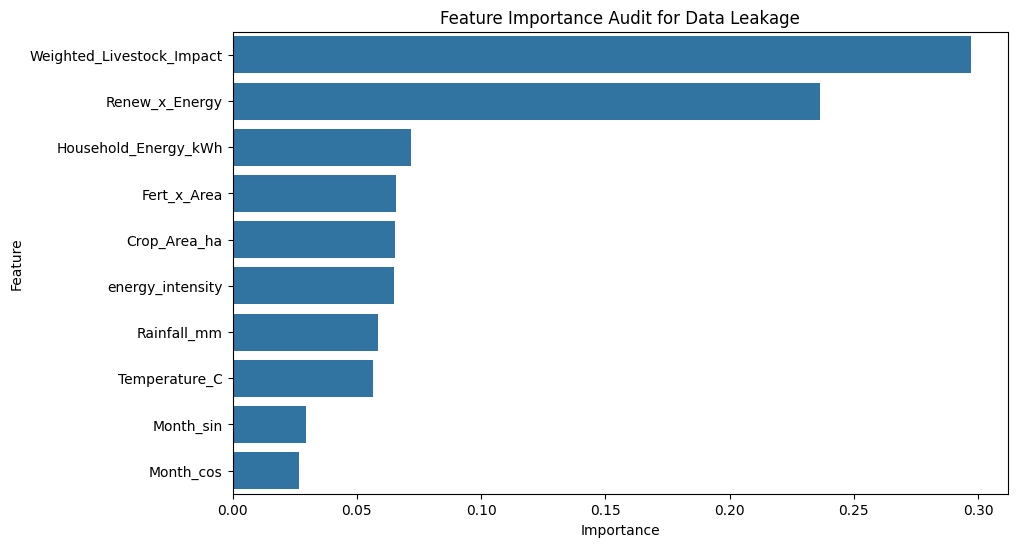

In [39]:
# 1. Extract feature names from the OneHotEncoder and Numerical features
# (Using the preprocessor from Model 2 as an example)
cat_encoder = pipeline_model2.named_steps['preprocessor'].named_transformers_['text_encode']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_cols2).tolist()
all_features = encoded_cat_features + numerical_cols2

# 2. Extract feature importances from the trained Random Forest
importances = pipeline_model2.named_steps['classifier'].feature_importances_

# 3. Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Top Features Driving the Accuracy ---")
print(importance_df.head(10))

# 4. Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Feature Importance Audit for Data Leakage")
plt.show()

In [ ]:
# 1. Count total duplicate rows in the raw dataset
duplicate_count = raw_df.duplicated().sum()
print(f"Number of perfectly duplicated rows: {duplicate_count}")

In [40]:
cow_df=cow_df.drop(['Region','Year','Month'], axis=1)

# 4. Feature Engineering
cow_weight = 2.0  # Approx tons of CO2e per cow/year
pig_weight = 0.3  # Approx tons of CO2e per pig/year

cow_df['Weighted_Livestock_Impact'] = (cow_df['Livestock_Cows'] * cow_weight) + (cow_df['Livestock_Pigs'] * pig_weight)
# 2. Advanced Density Feature: Connect the weighted impact with the land area
# cow_df['Livestock_Impact_per_Ha'] = cow_df['Weighted_Livestock_Impact'] / (cow_df['Crop_Area_ha'] + 1e-5)

cow_df['Fert_x_Area'] = cow_df['Fertilizer_Usage_kg'] / cow_df['Crop_Area_ha']
cow_df['Renew_x_Energy'] = cow_df['Renewable_Energy_Fraction'] * cow_df['Household_Energy_kWh']
# cow_df['emission_density'] = cow_df['Carbon_Emission_tCO2'] / (cow_df['Crop_Area_ha'] + 1e-5)
cow_df['energy_intensity'] = cow_df['Household_Energy_kWh'] / (cow_df['Crop_Area_ha'] + 1e-5)
cow_df=cow_df.drop(['Livestock_Pigs','Livestock_Cows','Renewable_Energy_Fraction','Carbon_Emission_tCO2','Fertilizer_Usage_kg'], axis=1)

# print a sample of dataset after preprocessing
cow_df.head()


,Crop_Type,Crop_Area_ha,Household_Energy_kWh,Temperature_C,Rainfall_mm,classes,Weighted_Livestock_Impact,Fert_x_Area,Renew_x_Energy,energy_intensity
0,Maize,37.3,296.6,23.6,70.7,Low,39.0,2.855228,172.028,7.951740
1,Wheat,47.4,408.8,24.9,275.5,High,248.8,2.128692,204.400,8.624471
2,Maize,28.7,479.3,21.8,35.7,Low,202.0,2.069686,464.921,16.700343
3,Rice,29.3,146.3,30.7,285.5,Low,130.6,4.194539,19.019,4.993172
4,Maize,25.7,233.9,23.3,76.2,Low,142.7,2.583658,210.510,9.101164


In [41]:
# Separate target from predictors
X = cow_df.drop(columns=['classes'])
y = cow_df['classes']

# Identify text (categorical) and numerical columns automatically
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# 3: Model

#1st Model

In [42]:
# Common in the 2 Models
preprocessor = ColumnTransformer(
    transformers=[
        # Converts text columns to 1s and 0s, ignores unseen words in test data safely
        ('text_encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        # Normalizes numerical columns to standard scales
        ('num_scale', StandardScaler(), numerical_cols)])

In [43]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,       # Number of decision trees in the forest
    max_depth=8,            # Maximum tree split levels to mitigate overfitting
    min_samples_leaf=4,     # Minimum samples allowed at a leaf node
    random_state=42,        # Standard seed for consistency
    n_jobs=-1,              # Uses all CPU cores for parallel tree building
    class_weight='balanced'
)

In [44]:
# The pipeline ensures text processing flows straight into model training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

In [45]:
# Split into 80% train and 20% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Training both the text-encoder and the Random Forest simultaneously
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text_encode',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Crop_Type']),
                                                 ('num_scale', StandardScaler(),
                                                  ['Crop_Area_ha',
                                                   'Household_Energy_kWh',
                                                   'Temperature_C',
                                                   'Rainfall_mm',
                                                   'Weighted_Livestock_Impact',
                                                   'Fert_x_Area',
                                                   'Renew_x_Energy',
                                                   'energy_intensity'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=4, n_jobs=-1,
                                        random_state=42))])

# 2nd Model by Grid search

In [11]:
# 1. Initialize the base classifier (as a step in a new pipeline)
# We will build a pipeline for GridSearchCV that includes the preprocessor.
# Create a pipeline combining the preprocessor and a RandomForestClassifier
# The preprocessor is already defined as 'preprocessor'
pipe_for_grid_search = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the existing preprocessor
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # A placeholder classifier
])

# 2. Define the parameter grid. Parameters need to be prefixed with the step name.
param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [6, 8, 12, None],
    'classifier__min_samples_leaf': [2, 4, 6],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight': ['balanced', None] # Tests handling class imbalance vs leaving it raw
}

# 3. Set up the Grid Search engine
grid_search = GridSearchCV(
    estimator=pipe_for_grid_search, # Use the pipeline as the estimator
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# 4. Execute Grid Search on your raw training data (the pipeline will preprocess it)
grid_search.fit(X_train, y_train)

# 5. Extract and print the ultimate parameters
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

# 6. Extract the optimized model for immediate deployment
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [46]:
from sklearn.pipeline import Pipeline

# The pipeline ensures text processing flows straight into model training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Split into 80% train and 20% validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Explicitly define model_pipeline here to ensure it includes the preprocessor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

# Training both the text-encoder and the Random Forest simultaneously
model_pipeline.fit(X_train, y_train)

ValueError: could not convert string to float: 'Wheat'

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Infer predictions on raw text test features
y_pred = model_pipeline.predict(X_test)

# Print comprehensive classification metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 87.17%

Classification Report:
               precision    recall  f1-score   support

        High       0.87      0.63      0.73        75
         Low       0.94      0.86      0.90       218
      Medium       0.83      0.94      0.88       293
        Safe       1.00      1.00      1.00        14

    accuracy                           0.87       600
   macro avg       0.91      0.86      0.88       600
weighted avg       0.88      0.87      0.87       600



In [ ]:
# Infer predictions on training features
y_train_pred = model_pipeline.predict(X_train)

# Print comprehensive classification metrics for training set
print(f"Training Accuracy Score: {accuracy_score(y_train, y_train_pred) * 100:.2f}%")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

Training Accuracy Score: 100.00%

Training Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00       317
         Low       1.00      1.00      1.00       814
      Medium       1.00      1.00      1.00      1161
        Safe       1.00      1.00      1.00       108

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400

